# 分类

## 鸢尾花数据分类

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

In [17]:
# ========== 1. 加载数据集 ==========
print("=" * 60)
print("1. 加载鸢尾花数据集")
print("=" * 60)

iris = load_iris()
X = iris.data          # 特征: 花萼长、花萼宽、花瓣长、花瓣宽
y = iris.target        # 标签: 0=Setosa, 1=Versicolor, 2=Virginica

print(f"特征矩阵形状: {X.shape}")
print(f"标签向量形状: {y.shape}")
print(f"特征名称: {iris.feature_names}")
print(f"类别名称: {iris.target_names}")

1. 加载鸢尾花数据集
特征矩阵形状: (150, 4)
标签向量形状: (150,)
特征名称: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
类别名称: ['setosa' 'versicolor' 'virginica']


In [18]:
# ========== 2. 探索性数据分析 ==========
print("\n" + "=" * 30)
print("2. 数据探索")
print("=" * 30)

# 显示前5个样本
print("前5个样本的特征:")
print(X[:5])
print("前5个样本的标签:", y[:5])

# 按类别统计样本数量
unique, counts = np.unique(y, return_counts=True)
print(f"各类别样本数:")
for label, count in zip(iris.target_names[unique], counts):
    print(f"  {label}: {count} 个")


2. 数据探索
前5个样本的特征:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
前5个样本的标签: [0 0 0 0 0]
各类别样本数:
  setosa: 50 个
  versicolor: 50 个
  virginica: 50 个


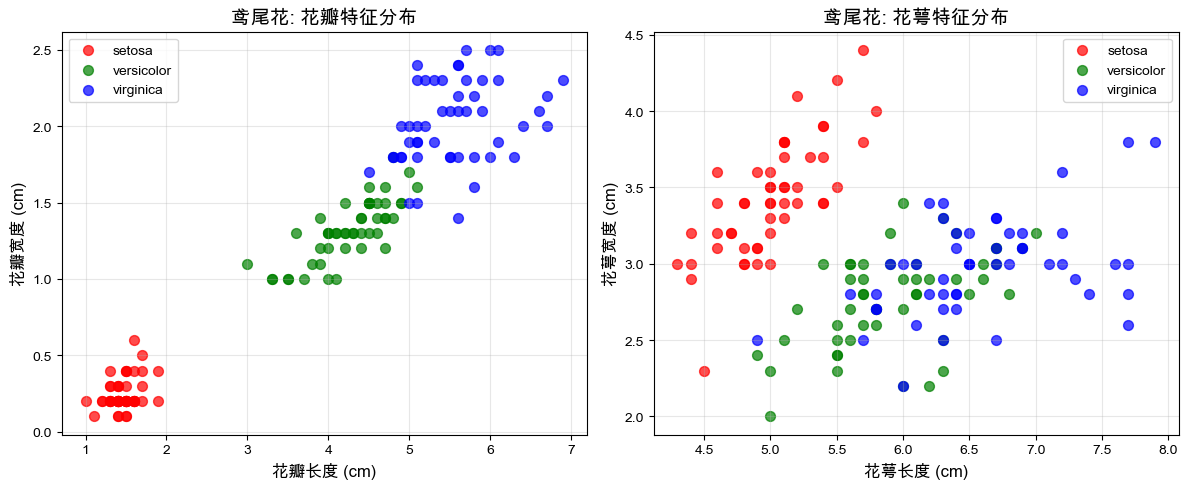

In [6]:
# ========== 3. 可视化：花瓣长度 vs 花瓣宽度 ==========
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左图：花瓣
ax1 = axes[0]
colors = ['red', 'green', 'blue']
labels = iris.target_names

for i, label_name in enumerate(labels):
    mask = y == i
    ax1.scatter(X[mask, 2], X[mask, 3], 
                c=colors[i], label=label_name, s=50, alpha=0.7)

ax1.set_xlabel('花瓣长度 (cm)', fontsize=12)
ax1.set_ylabel('花瓣宽度 (cm)', fontsize=12)
ax1.set_title('鸢尾花: 花瓣特征分布', fontsize=14)
ax1.legend()
ax1.grid(alpha=0.3)

# 右图：花萼
ax2 = axes[1]
for i, label_name in enumerate(labels):
    mask = y == i
    ax2.scatter(X[mask, 0], X[mask, 1], 
                c=colors[i], label=label_name, s=50, alpha=0.7)

ax2.set_xlabel('花萼长度 (cm)', fontsize=12)
ax2.set_ylabel('花萼宽度 (cm)', fontsize=12)
ax2.set_title('鸢尾花: 花萼特征分布', fontsize=14)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# ========== 4. 训练/测试集划分 ==========
print("\n" + "=" * 30)
print("3. 划分训练集和测试集")
print("=" * 30)
# 按 70% 训练, 30% 测试 的比例划分
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"训练集样本数: {len(X_train)}")
print(f"测试集样本数: {len(X_test)}")
print(f"训练集各类别分布: {np.bincount(y_train)}")
print(f"测试集各类别分布: {np.bincount(y_test)}")


3. 划分训练集和测试集
训练集样本数: 105
测试集样本数: 45
训练集各类别分布: [35 35 35]
测试集各类别分布: [15 15 15]


In [9]:
# ========== 5. 特征标准化 ==========
print("\n" + "=" * 60)
print("4. 特征标准化")
print("=" * 60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("标准化前:")
print(f"  特征均值: {X_train.mean(axis=0)}")
print(f"  特征标准差: {X_train.std(axis=0)}")
print("标准化后:")
print(f"  特征均值: {X_train_scaled.mean(axis=0)}")
print(f"  特征标准差: {X_train_scaled.std(axis=0)}")


4. 特征标准化
标准化前:
  特征均值: [5.87333333 3.0552381  3.7847619  1.20571429]
  特征标准差: [0.85882164 0.45502087 1.77553646 0.77383751]
标准化后:
  特征均值: [ 2.38327876e-15 -1.12145742e-15 -1.37456184e-16 -6.97854473e-17]
  特征标准差: [1. 1. 1. 1.]


In [25]:
# ========== 6. 训练KNN分类器 ==========
print("\n" + "=" * 40)
print("5. 训练K近邻分类器 (k=5)")
print("=" * 40)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)


5. 训练K近邻分类器 (k=5)


KNeighborsClassifier()

In [27]:
# ========== 7. 模型预测与评估 ==========
y_pred = knn.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"准确率: {accuracy * 100:.2f}%")
print(f"测试集上预测错误的样本数: {(y_pred != y_test).sum()} / {len(y_test)}")

准确率: 91.11%
测试集上预测错误的样本数: 4 / 45



6. 混淆矩阵
混淆矩阵:
[[15  0  0]
 [ 0 15  0]
 [ 0  4 11]]


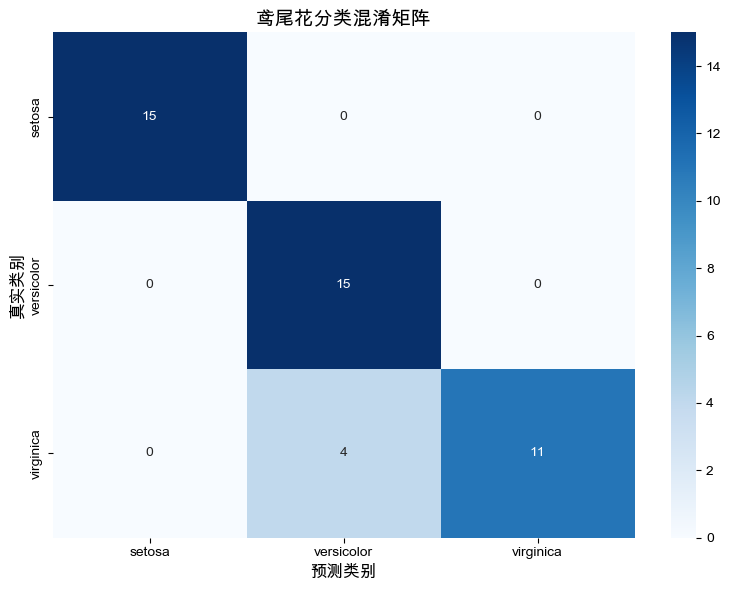

In [28]:
# ========== 8. 混淆矩阵 ==========
print("\n" + "=" * 60)
print("6. 混淆矩阵")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred)
print("混淆矩阵:")
print(cm)

# 可视化混淆矩阵
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, 
            yticklabels=iris.target_names,
            ax=ax)
ax.set_xlabel('预测类别', fontsize=12)
ax.set_ylabel('真实类别', fontsize=12)
ax.set_title('鸢尾花分类混淆矩阵', fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
# ========== 9. 分类报告 ==========
print("\n" + "=" * 60)
print("7. 分类报告")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=iris.target_names))


7. 分类报告
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45



In [31]:
# ========== 10. 寻找最佳 k 值 ==========
print("\n" + "=" * 60)
print("8. 寻找最佳K值")
print("=" * 60)

k_values = range(1, 31)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred_k))

best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print(f"最佳K值: {best_k}")
print(f"最佳准确率: {best_accuracy * 100:.2f}%")


8. 寻找最佳K值
最佳K值: 9
最佳准确率: 95.56%


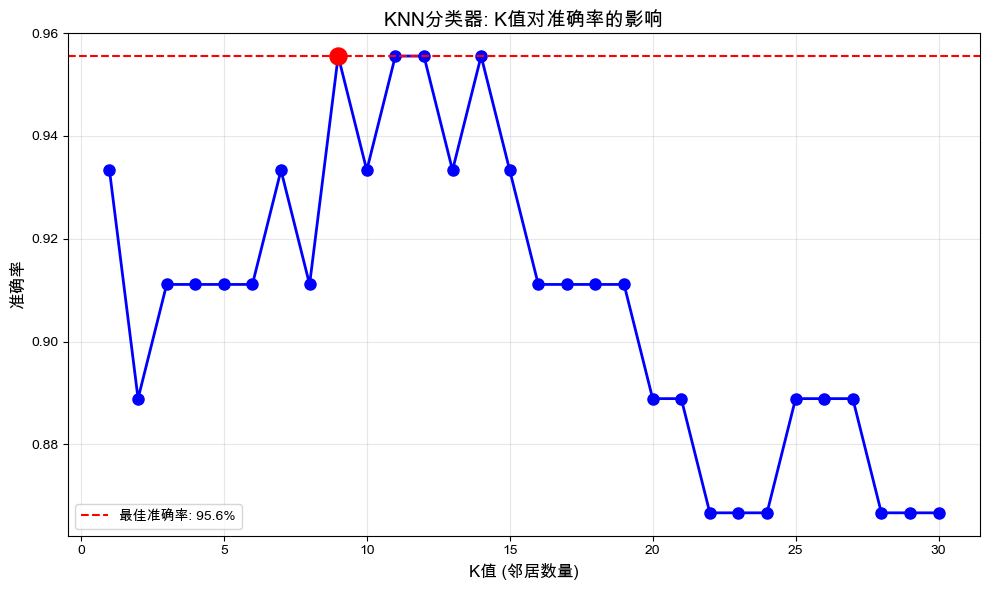

In [32]:
# 可视化 k值与准确率的关系
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_values, accuracies, 'bo-', linewidth=2, markersize=8)
ax.axhline(y=best_accuracy, color='r', linestyle='--', 
           label=f'最佳准确率: {best_accuracy*100:.1f}%')
ax.scatter(best_k, best_accuracy, color='red', s=150, zorder=5)
ax.set_xlabel('K值 (邻居数量)', fontsize=12)
ax.set_ylabel('准确率', fontsize=12)
ax.set_title('KNN分类器: K值对准确率的影响', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# ========== 11. 使用最佳K值重新训练 ==========
print("\n" + "=" * 60)
print("9. 使用最佳K值重新训练")
print("=" * 60)

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_best = knn_best.predict(X_test_scaled)
best_acc = accuracy_score(y_test, y_pred_best)

print(f"K={best_k} 时的准确率: {best_acc * 100:.2f}%")


9. 使用最佳K值重新训练
K=9 时的准确率: 95.56%


In [16]:
# ========== 12. 新样本预测演示 ==========
print("\n" + "=" * 60)
print("10. 新样本预测演示")
print("=" * 60)

# 创建一个新样本: 花萼长=5.1, 花萼宽=3.5, 花瓣长=1.4, 花瓣宽=0.2
# 这是一朵典型山鸢尾的特征
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])

# 先标准化，再预测
new_sample_scaled = scaler.transform(new_sample)
prediction = knn_best.predict(new_sample_scaled)
prediction_proba = knn_best.predict_proba(new_sample_scaled)

print(f"新样本: 花萼长=5.1cm, 花萼宽=3.5cm, 花瓣长=1.4cm, 花瓣宽=0.2cm")
print(f"预测类别: {iris.target_names[prediction[0]]}")
print(f"预测概率: ")
for i, prob in enumerate(prediction_proba[0]):
    print(f"  {iris.target_names[i]}: {prob * 100:.1f}%")

# ========== 总结 ==========
print("\n" + "=" * 60)
print("【课堂总结】")
print("=" * 60)
print(f"1. 数据集: {X.shape[0]} 个样本, {X.shape[1]} 个特征")
print(f"2. 分类器: K近邻 (KNN)")
print(f"3. 最佳K值: {best_k}")
print(f"4. 测试集准确率: {best_acc * 100:.2f}%")
print("5. 结论: 鸢尾花分类是一个简单但典型的分类问题")
print("   KNN算法在该数据集上表现良好, 准确率超过95%")


10. 新样本预测演示
新样本: 花萼长=5.1cm, 花萼宽=3.5cm, 花瓣长=1.4cm, 花瓣宽=0.2cm
预测类别: setosa
预测概率: 
  setosa: 100.0%
  versicolor: 0.0%
  virginica: 0.0%

【课堂总结】
1. 数据集: 150 个样本, 4 个特征
2. 分类器: K近邻 (KNN)
3. 最佳K值: 9
4. 测试集准确率: 95.56%
5. 结论: 鸢尾花分类是一个简单但典型的分类问题
   KNN算法在该数据集上表现良好, 准确率超过95%
